<a href="https://colab.research.google.com/github/guravharshvardhan/Deep-Learning/blob/main/Experiment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
model_fixed = create_model()

model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9219 - loss: 0.2659 - val_accuracy: 0.9582 - val_loss: 0.1414
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9653 - loss: 0.1130 - val_accuracy: 0.9668 - val_loss: 0.1084
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0775 - val_accuracy: 0.9711 - val_loss: 0.0967
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9819 - loss: 0.0578 - val_accuracy: 0.9705 - val_loss: 0.1072
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9850 - loss: 0.0461 - val_accuracy: 0.9744 - val_loss: 0.0942
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9879 - loss: 0.0360 - val_accuracy: 0.9734 - val_loss: 0.0916
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9899 - loss: 0.0299 - val_accuracy: 0.9714 - val_loss: 0.1104
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0251 - 

In [ ]:
model_lr = create_model()

model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history_lr = model_lr.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9221 - loss: 0.2626 - val_accuracy: 0.9587 - val_loss: 0.1374 - learning_rate: 0.0010
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9653 - loss: 0.1141 - val_accuracy: 0.9682 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9754 - loss: 0.0797 - val_accuracy: 0.9685 - val_loss: 0.1001 - learning_rate: 0.0010
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9821 - loss: 0.0587 - val_accuracy: 0.9743 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9858 - loss: 0.0451 - val_accuracy: 0.9720 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9753 - val_loss: 0.0842 - learning_rate: 0.0010
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9901 - l

In [ ]:
model_final = create_model()

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9218 - loss: 0.2651 - val_accuracy: 0.9635 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9649 - loss: 0.1148
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9660 - loss: 0.1107 - val_accuracy: 0.9663 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9832 - loss: 0.0569 - val_accuracy: 0.9751 - val_loss: 0.0856 - learning_rate: 1.0000e-04
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9863 - loss: 0.0481 - val_accuracy: 0.9750 - val_loss: 0.0823 - learning_rate: 1.0000e-04
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9879 - loss: 0.0430 - val_accuracy: 0.9743 - val_loss: 0.0823 - learning_rate: 1.0000e-04
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accurac

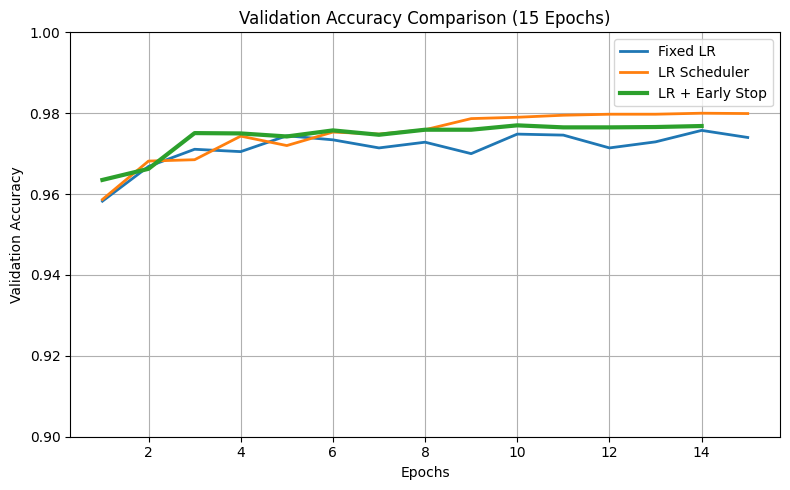

In [ ]:
plt.figure(figsize=(8,5))

epochs_fixed = range(1, len(history_fixed.history['val_accuracy'])+1)
epochs_lr = range(1, len(history_lr.history['val_accuracy'])+1)
epochs_final = range(1, len(history_final.history['val_accuracy'])+1)

plt.plot(epochs_fixed, history_fixed.history['val_accuracy'], linewidth=2, label="Fixed LR")
plt.plot(epochs_lr, history_lr.history['val_accuracy'], linewidth=2, label="LR Scheduler")
plt.plot(epochs_final, history_final.history['val_accuracy'], linewidth=3, label="LR + Early Stop")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison (15 Epochs)")
plt.legend()
plt.ylim(0.90, 1.0)
plt.grid()   # small improvement
plt.tight_layout()
plt.show()